In [66]:
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision import models
from torchvision.transforms import InterpolationMode
from torchvision.datasets import VOCSegmentation

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torch.utils.data import sampler
from torch.utils.data import DataLoader, Dataset

import os
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random
import numpy as np
from collections import defaultdict

In [67]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

# Dataset and VGG

In [68]:
# Class to perform resizing and cropping of Pascal images
# Takes resize and crop dimensions -> outputs img, mask tensors resized
# We need to ensure that the img and mask correspond (same region is cropped)
class VOCTransform:
    def __init__(self, resize=256, crop=224):
        self.resize = resize
        self.crop = crop

    def __call__(self, img, mask):
        img = TF.resize(img, self.resize)
        mask = TF.resize(mask, self.resize, interpolation=InterpolationMode.NEAREST)

        i, j, h, w = T.RandomCrop.get_params(img, (self.crop, self.crop))

        img = TF.crop(img, i, j, h, w)
        mask = TF.crop(mask, i, j, h, w)

        img = TF.to_tensor(img)
        mask = TF.pil_to_tensor(mask)

        return img, mask

In [69]:
# Transform images as they load
class VOCDataset(VOCSegmentation):
    def __init__(self, root, year, image_set, transform=None, download=False):
        super().__init__(root=root, year=year, image_set=image_set, download=download)
        self.joint_transform = transform

    def __getitem__(self, index):
        img, mask = super().__getitem__(index)

        if self.joint_transform:
            img, mask = self.joint_transform(img, mask)

        return img, mask.squeeze(0).long()

In [70]:
VAL_SPLIT = 0.1
PASCAL_BATCH_SIZE = 8
PASCAL_TEST_BATCH_SIZE = 1
NUM_WORKERS = 0

joint_transform = VOCTransform(resize=256, crop=224)

# Load data train/test splits
voc_full_train = VOCDataset(
    './data',
    year='2012',
    image_set='train',
    transform=joint_transform,
    download=True
)

voc_test = VOCDataset(
    './data',
    year='2012',
    image_set='val',
    transform=joint_transform,
    download=True
)

# Get validation split from train split
val_size = int(len(voc_full_train) * VAL_SPLIT)
train_size = len(voc_full_train) - val_size

voc_train, voc_val = random_split(voc_full_train, [train_size, val_size])

# Data loaders (for batched images)
voc_train_loader = DataLoader(
    voc_train,
    batch_size=PASCAL_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

voc_val_loader = DataLoader(
    voc_val,
    batch_size=PASCAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

voc_test_loader = DataLoader(
    voc_test,
    batch_size=PASCAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

In [71]:
# Load pretrained VGG16
vgg_model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# Building Hypercolumn Dataset Splits

In [72]:
def extract_feature_maps(x, model, layers = [3, 8, 15, 22, 29]):
    features = {}

    for i, layer in enumerate(model.features):
        x = layer(x)

        if i in layers:
            features[i] = x

    return features

In [73]:
def build_hypercolumns(feature_dict):
    """
    feature_dict: dict[layer_idx -> tensor[B, C, H_i, W_i]]

    Returns:
        tensor [B, Z, H, W]
        where Z = sum of all channel dimensions
    """

    # get reference spatial size (highest resolution)
    first_map = list(feature_dict.values())[0]
    B, _, H, W = first_map.shape

    upsampled_maps = []

    for fmap in feature_dict.values():
        if fmap.shape[2:] != (H, W):
            fmap = F.interpolate(
                fmap,
                size=(H, W),
                mode='bilinear',
                align_corners=False
            )

        upsampled_maps.append(fmap)

    # concatenate channels
    hypercolumns = torch.cat(upsampled_maps, dim=1)

    return hypercolumns

In [74]:
def sample_hypercolumns_per_image(hyper, label, samples_per_class=3):
    """
    hyper: torch tensor [Z, H, W] -> hypercolumns of one image
    label: torch tensor [H, W] -> class label per pixel
    samples_per_class: int, number of pixels to sample per class

    Returns:
        list of tuples: [(feature, label), ...]
            feature: [Z, 1, 1]
            label: [1, 1]
    """
    Z, H, W = hyper.shape
    sampled_list = []

    # get unique classes in this image
    classes = torch.unique(label)
    classes = classes[classes != 255] # ignore the contour from labeled images as this is not a class

    for cls in classes:
        # find pixels belonging to this class
        mask = (label == cls)  # [H, W]
        indices = mask.nonzero(as_tuple=False)  # [[i, j], ...]

        # if fewer pixels than samples_per_class, take all
        if indices.shape[0] < samples_per_class:
            selected_indices = indices
        else:
            perm = torch.randperm(indices.shape[0])
            selected_indices = indices[perm[:samples_per_class]]

        # extract hypercolumns for selected pixels
        for idx in selected_indices:
            i, j = idx
            feature = hyper[:, i, j].unsqueeze(-1).unsqueeze(-1)  # [Z, 1, 1]
            lbl = label[i, j].unsqueeze(0).unsqueeze(0)           # [1, 1]
            sampled_list.append((feature, lbl))

    return sampled_list

In [ ]:
import torch
from torch.utils.data import IterableDataset

class HypercolumnPixelDataset(IterableDataset):
    def __init__(self, voc_loader, vgg_model, device='mps', samples_per_class=3):
        """
        voc_loader: DataLoader yielding (img_batch, label_batch)
        vgg_model: pretrained VGG feature extractor
        samples_per_class: #pixels per class per image
        """
        self.voc_loader = voc_loader
        self.vgg = vgg_model.eval().to(device)
        self.samples_per_class = samples_per_class
        self.device = device
        self.len = None

    def __iter__(self):
        for img_batch, lbl_batch in self.voc_loader:
            B = img_batch.shape[0]
            img_batch = img_batch.to(self.device)
            lbl_batch = lbl_batch.to(self.device)

            # forward batch through VGG
            with torch.no_grad():
                feature_maps = extract_feature_maps(img_batch, self.vgg)  # [B, ..., H, W]
                hypercolumns = build_hypercolumns(feature_maps)           # [B, Z, H, W]

            # sample pixels per image
            for i in range(B):
                hyper = hypercolumns[i]  # [Z, H, W]
                lbl = lbl_batch[i]       # [H, W]

                sampled = sample_hypercolumns_per_image(hyper, lbl, self.samples_per_class) # list[(hyper, lbl)]

                # sampled pixel
                for hyp, label in sampled:
                    yield hyp.view(-1), label.view(-1) # around 8 * 22 for each VOC batch

In [76]:
HYPER_BATCH_SIZE = 64
PIXEL_SAMPLES = 3 # controls how many (hypercolumn, label) pairs to get per pixel class for a given sample
DEVICE = get_device()

# Hyperpixel pair dataset and loaders
train_pixel_dataset = HypercolumnPixelDataset(voc_train_loader, vgg_model, samples_per_class=PIXEL_SAMPLES, device = DEVICE)
train_pixel_loader = DataLoader(train_pixel_dataset, batch_size=HYPER_BATCH_SIZE, drop_last=True)

val_pixel_dataset = HypercolumnPixelDataset(voc_val_loader, vgg_model, samples_per_class=PIXEL_SAMPLES, device = DEVICE)
val_pixel_loader = DataLoader(val_pixel_dataset, batch_size=HYPER_BATCH_SIZE, drop_last=True)

test_pixel_dataset = HypercolumnPixelDataset(voc_test_loader, vgg_model, samples_per_class=PIXEL_SAMPLES, device = DEVICE)
test_pixel_loader = DataLoader(test_pixel_dataset, batch_size=HYPER_BATCH_SIZE, drop_last=True)

# Hypercolumn Classifier

## Architecture

In [77]:
class HC_Classifier(nn.Module):
    def __init__(self, in_dim=1472, num_classes=21):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_dim, 512, 3, padding=1),  
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Conv2d(512, 256, 3, padding=1),     
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Conv2d(256, 128, 3, padding=1),    
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Conv2d(128, 64, 3, padding=1),     
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, num_classes, 1)         
        )

    def forward(self, x):
        x = F.normalize(x, dim=1)
        return self.net(x)

## Training

In [78]:
def val(loader, model, criterion, device):
    num_correct = 0
    num_samples = 0
    total_loss = 0
    num_batches = 0
    model.eval() # set model to evaluation mode

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device).unsqueeze(-1).unsqueeze(-1) # [B, Z, 1, 1]
            y = y.to(device).view(-1)

            out = model(x)           # [B, C, 1, 1]
            out = out.squeeze(-1).squeeze(-1)  # [B, C]
            loss = criterion(out, y) # needed to graph per epoch loss and accuracy
            preds = out.argmax(dim=1)

            num_correct += (preds == y).sum().item()
            num_samples += y.size(0)

            # for computation of per epoch avg loss and acc
            total_loss += loss.item()
            num_batches += 1

        acc = num_correct / num_samples
        print('Eval %d / %d correct (%.2f)' % (num_correct, num_samples, 100 * acc))

    avg_loss = total_loss / num_batches

    return avg_loss, acc

In [79]:
def test_hc_classifier(loader, model, device):
    """
    Evaluates a hypercolumn pixel classifier on a dataset, returns accuracy.

    Args:
        loader : DataLoader yielding (x, y) pairs
                 x: [B, Z, 1, 1] hypercolumns
                 y: [B] pixel labels
        model  : HC classifier
        device : torch.device

    Returns:
        acc    : overall pixel accuracy
    """
    num_correct = 0
    num_samples = 0
    model.eval()  # set model to evaluation mode

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device).unsqueeze(-1).unsqueeze(-1)  # [B, Z, 1, 1]
            y = y.to(device).view(-1)                     # [B]

            out = model(x)                                # [B, C, 1, 1]
            out = out.squeeze(-1).squeeze(-1)            # [B, C]

            preds = out.argmax(dim=1)                     # [B]

            num_correct += (preds == y).sum().item()
            num_samples += y.size(0)

    acc = num_correct / num_samples
    print(f"Accuracy: {num_correct}/{num_samples} ({100*acc:.2f}%)")

    return acc

In [80]:
def train_hc_classifier(loader_train, loader_val, model, optimizer, scheduler, device, epochs):

    model = model.to(device)
    criterion = torch.nn.CrossEntropyLoss()

    epoch_loss_val = []
    epoch_acc_val = []
    epoch_loss_train = []
    epoch_acc_train = []

    for e in range(epochs):

        model.train()

        train_loss_sum = 0
        train_correct = 0
        train_samples = 0
        num_batches = 0

        for t, (x, y) in enumerate(loader_train):

            x = x.to(device).unsqueeze(-1).unsqueeze(-1)  # [B, Z, 1, 1]
            y = y.to(device).view(-1)                     # [B]

            out = model(x)
            out = out.squeeze(-1).squeeze(-1)             # [B, C]

            loss = criterion(out, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            preds = out.argmax(dim=1)

            train_correct += (preds == y).sum().item()
            train_samples += y.size(0)
            train_loss_sum += loss.item()
            num_batches += 1

            if t % 64 == 0:
                print(f"Epoch {e}, Iteration {t}, loss = {loss.item():.4f}")

        avg_train_loss = train_loss_sum / num_batches
        train_acc = train_correct / train_samples

        epoch_loss_train.append(avg_train_loss)
        epoch_acc_train.append(train_acc)

        # validation
        e_loss_val, e_acc_val = val(loader_val, model, criterion, device)

        epoch_loss_val.append(e_loss_val)
        epoch_acc_val.append(e_acc_val)

        # step scheduler
        scheduler.step()

        print(f"Epoch {e} LR: {scheduler.get_last_lr()[0]:.6f}")

    return epoch_loss_train, epoch_acc_train, epoch_loss_val, epoch_acc_val

In [81]:
LR = 1e-2
WEIGHT_DECAY = 1e-4
P = 0.9
EPOCHS = 50
DEVICE = get_device()

hc_classifier = HC_Classifier()

optimizer = optim.SGD(
    hc_classifier.parameters(),
    lr=LR,
    momentum=P,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

loss_train, acc_train, loss_val, acc_val = train_hc_classifier(
    train_pixel_loader,
    val_pixel_loader,
    hc_classifier,
    optimizer,
    scheduler,
    DEVICE,
    EPOCHS
)

Epoch 0, Iteration 0, loss = 3.2466
Epoch 0, Iteration 64, loss = 2.1431
Epoch 0, Iteration 128, loss = 1.8439
Eval 539 / 1024 correct (52.64)
Epoch 0 LR: 0.009990
Epoch 1, Iteration 0, loss = 1.9022
Epoch 1, Iteration 64, loss = 1.7698
Epoch 1, Iteration 128, loss = 1.7694
Eval 580 / 1024 correct (56.64)
Epoch 1 LR: 0.009961
Epoch 2, Iteration 0, loss = 1.4188
Epoch 2, Iteration 64, loss = 1.4560
Epoch 2, Iteration 128, loss = 1.7456
Eval 582 / 1024 correct (56.84)
Epoch 2 LR: 0.009911
Epoch 3, Iteration 0, loss = 1.2752
Epoch 3, Iteration 64, loss = 1.8784
Epoch 3, Iteration 128, loss = 1.7298
Eval 589 / 1024 correct (57.52)
Epoch 3 LR: 0.009843
Epoch 4, Iteration 0, loss = 1.3037
Epoch 4, Iteration 64, loss = 1.4533
Epoch 4, Iteration 128, loss = 1.8553
Eval 614 / 1024 correct (59.96)
Epoch 4 LR: 0.009755
Epoch 5, Iteration 0, loss = 1.5664
Epoch 5, Iteration 64, loss = 1.6002
Epoch 5, Iteration 128, loss = 1.5157
Eval 623 / 1024 correct (60.84)
Epoch 5 LR: 0.009649
Epoch 6, Iterati

In [82]:
torch.save(hc_classifier.state_dict(), "hc_classifier.pth")

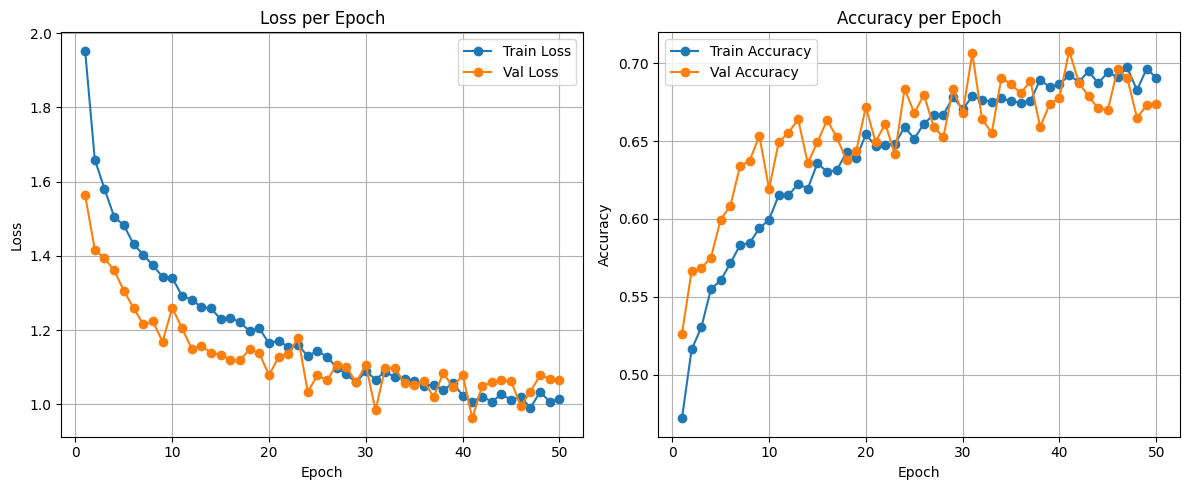

In [83]:
epochs = range(1, len(loss_train) + 1)

plt.figure(figsize=(12,5))

# loss plot
plt.subplot(1,2,1)
plt.plot(epochs, loss_train, marker='o', label="Train Loss")
plt.plot(epochs, loss_val, marker='o', label="Val Loss")
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# accuracy plot
plt.subplot(1,2,2)
plt.plot(epochs, acc_train, marker='o', label="Train Accuracy")
plt.plot(epochs, acc_val, marker='o', label="Val Accuracy")
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# TESTING

## Single Pixel Classification

In [84]:
DEVICE = get_device()
test_acc = test_hc_classifier(test_pixel_loader, hc_classifier, DEVICE)
print("Final accuracy score: ", test_acc)

Accuracy: 6931/10432 (66.44%)
Final accuracy score:  0.6643980061349694


## Full Image Segmentation

In [85]:
# Full architecture (full pipeline)
class HC_Image_Classifier(nn.Module):

    def __init__(self, path="./hc_classifier.pth", in_dim=1472, num_classes=21):
        super().__init__()

        self.vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        self.hc_classifier = HC_Classifier(in_dim, num_classes)

        self.hc_classifier.load_state_dict(torch.load(path, map_location="cpu"))

        # freeze VGG
        for p in self.vgg.parameters():
            p.requires_grad = False

        self.vgg.eval()

    def forward(self, x):
        feature_maps = extract_feature_maps(x, self.vgg)
        hyper_columns = build_hypercolumns(feature_maps)  # [B, Z, H, W]

        hyper_columns = F.normalize(hyper_columns, dim=1)

        logits = self.hc_classifier(hyper_columns)  # [B, num_classes, H, W]

        pred = logits.argmax(dim=1)

        return pred

In [86]:
def compute_iou(pred, target):
    """
    Computes per class IoU and mean IoU score across classes
    
    pred:   Tensor [H, W] predicted labels
    target: Tensor [H, W] ground truth labels

    Returns:
        dict mapping class -> IoU
        mean IoU
    """

    classes = torch.unique(target)
    ious = {}

    for cls in classes:
        pred_c = pred == cls
        target_c = target == cls

        intersection = torch.logical_and(pred_c, target_c).sum().float()
        union = torch.logical_or(pred_c, target_c).sum().float()

        if union == 0:
            iou = torch.nan
        else:
            iou = intersection / union

        ious[int(cls)] = iou.item()

    miou = torch.tensor(list(ious.values())).mean()

    return ious, miou.item()

In [87]:
def test(loader, model, device):
    model = model.to(device)
    model.eval()

    total_miou = 0
    num_images = 0

    # class -> list of IoUs
    class_iou = defaultdict(list)

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)   # [B, Z, H, W]
            y = y.to(device)   # [B, H, W]

            preds = model(x)               # [B, H, W]

            B = preds.shape[0]

            for i in range(B):
                pred_img = preds[i]
                target_img = y[i]

                ious, miou = compute_iou(pred_img, target_img)

                total_miou += miou
                num_images += 1

                # accumulate per-class IoUs
                for cls, iou in ious.items():
                    class_iou[cls].append(iou)

    # dataset mean mIoU
    dataset_miou = total_miou / num_images

    # compute per-class averages
    mean_iou_per_class = {}

    for cls, values in class_iou.items():
        mean_iou_per_class[cls] = sum(values) / len(values)

    print(f"\nDataset mIoU: {dataset_miou:.4f}\n")

    print("Per-class IoU:")
    for cls, val in sorted(mean_iou_per_class.items()):
        print(f"Class {cls}: {val:.4f}")

    return dataset_miou, mean_iou_per_class

In [88]:
# model = HC_Image_Classifier()
# mean_miou, mean_class_iou = test(voc_test_loader, model, DEVICE)

# VISUALIZATIONS

In [89]:
# Dictionary to map class integers to labels
voc_classes = {
    0: "Background",
    1: "Aeroplane",
    2: "Bicycle",
    3: "Bird",
    4: "Boat",
    5: "Bottle",
    6: "Bus",
    7: "Car",
    8: "Cat",
    9: "Chair",
    10: "Cow",
    11: "Dining table",
    12: "Dog",
    13: "Horse",
    14: "Motorbike",
    15: "Person",
    16: "Pottedplant",
    17: "Sheep",
    18: "Sofa",
    19: "Train",
    20: "Tvmonitor"
}

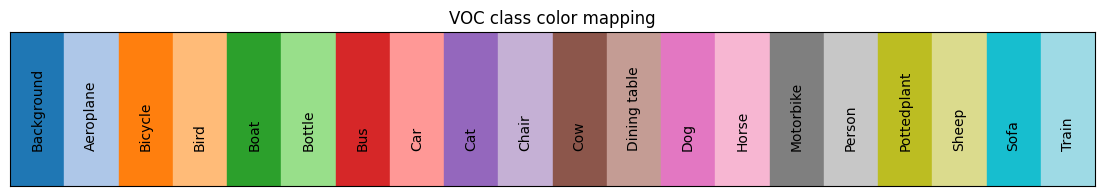

In [90]:
NUM_CLASSES = 20
fig, ax = plt.subplots(figsize=(14, 2))

norm = mcolors.BoundaryNorm(boundaries=range(NUM_CLASSES + 1),
                            ncolors=NUM_CLASSES)
cmap = plt.get_cmap("tab20", NUM_CLASSES)

for cls in range(NUM_CLASSES):
    ax.add_patch(plt.Rectangle((cls, 0), 1, 1, color=cmap(cls)))
    
    label = voc_classes.get(cls, str(cls))
    ax.text(cls + 0.5, 0.25, label, ha='center', rotation=90)

ax.set_xlim(0, NUM_CLASSES)
ax.set_ylim(0, 1)

ax.set_xticks([])
ax.set_yticks([])

ax.set_title("VOC class color mapping")

plt.show()

Adding a color map here for reference

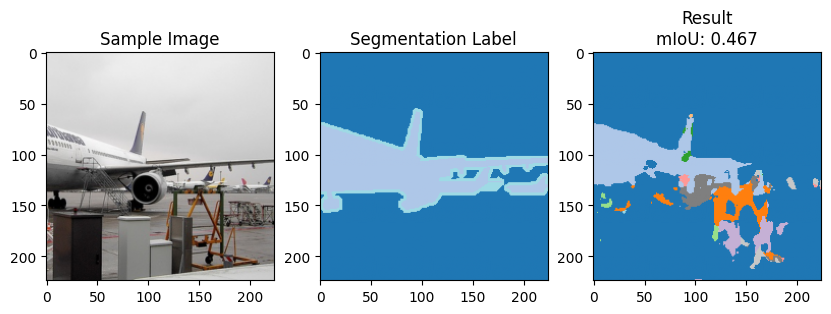

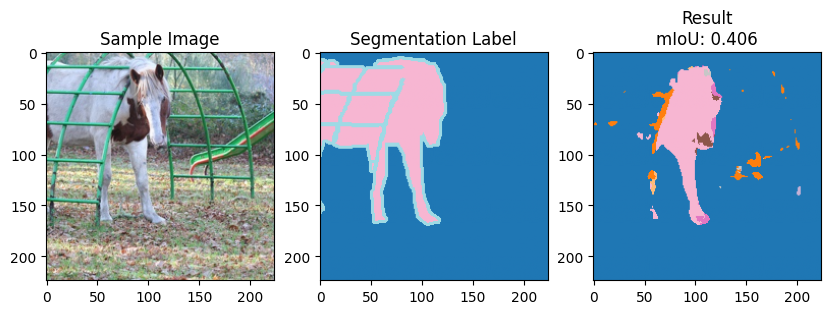

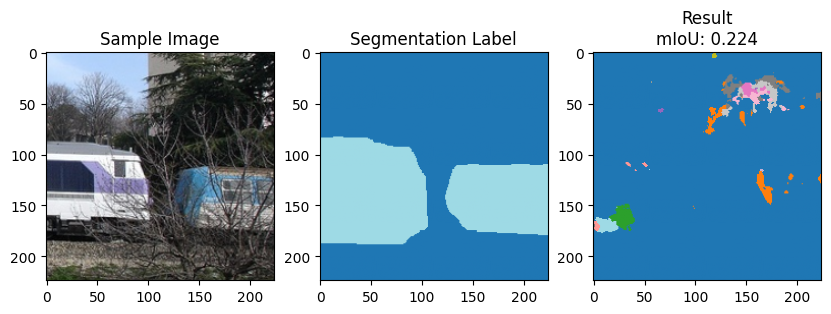

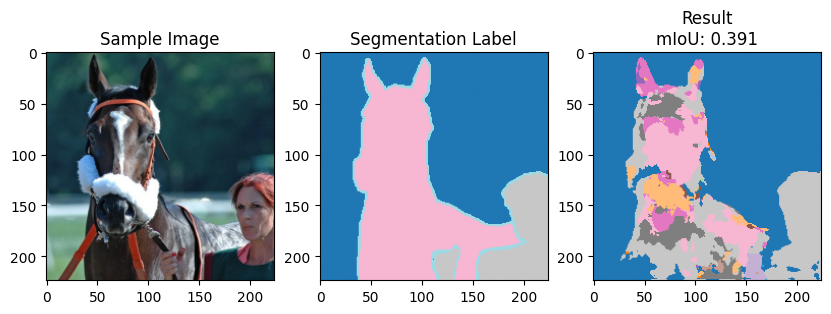

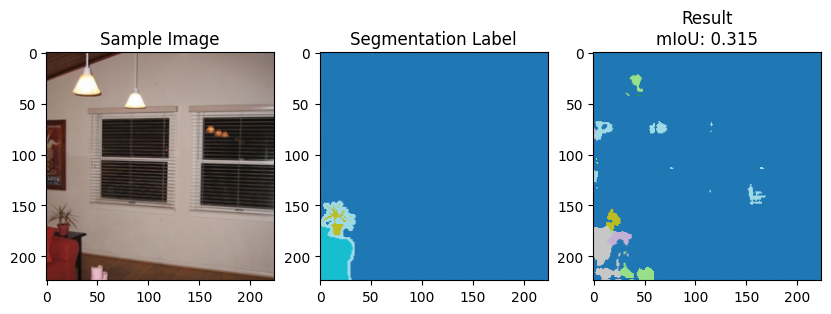

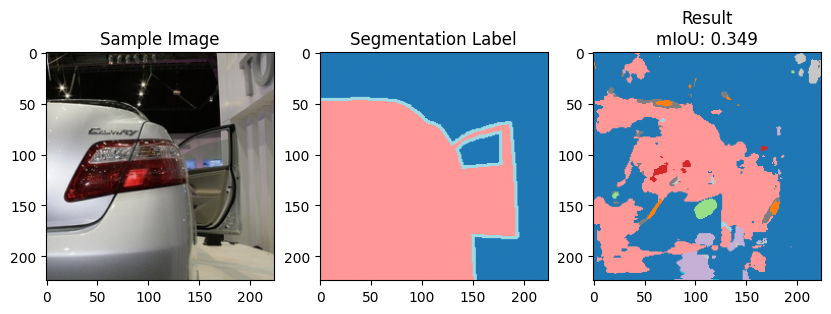

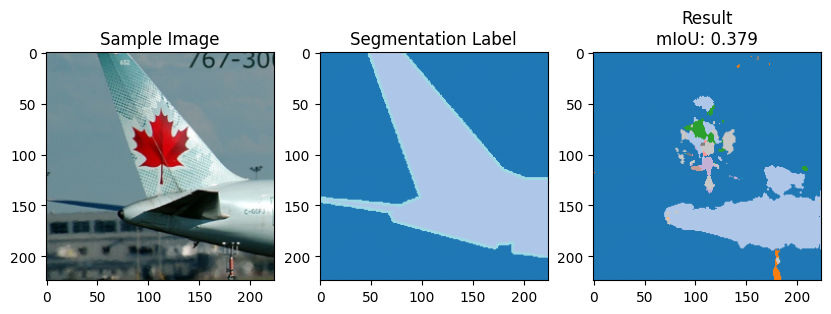

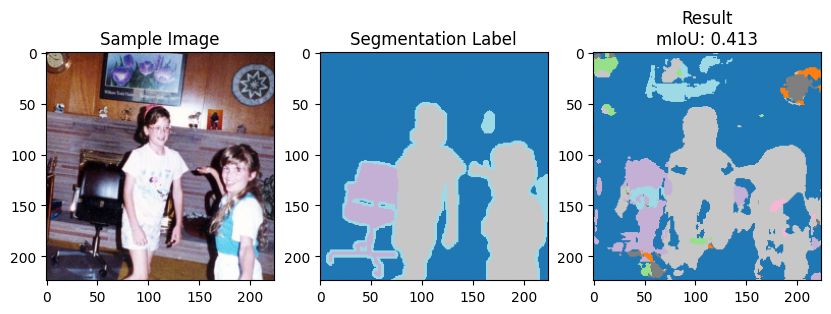

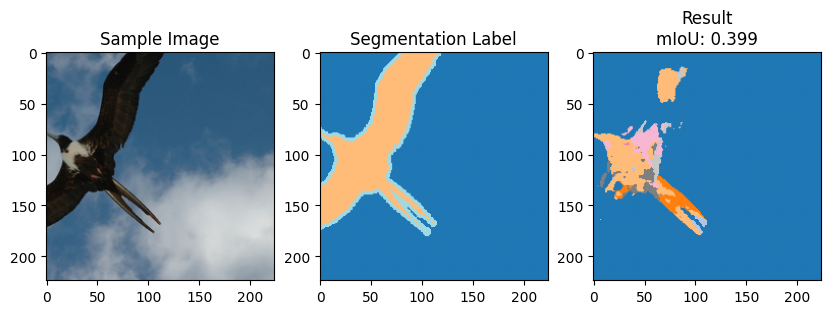

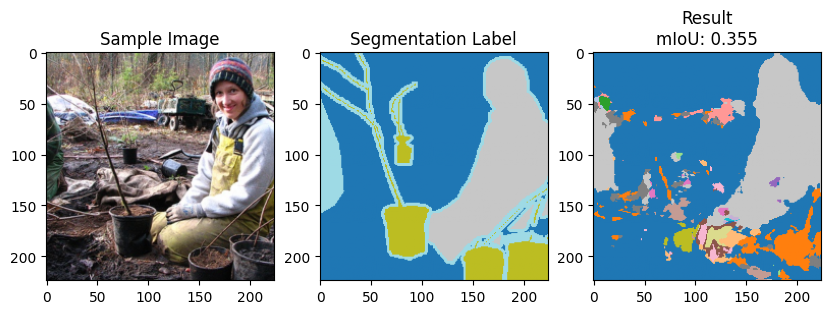

In [91]:
DEVICE = get_device()

model = HC_Image_Classifier().to(DEVICE)
model.eval()

for i, (img, lbl) in enumerate(voc_test_loader):
    if i == 10:
        break

    img = img.to(DEVICE)

    with torch.no_grad():
        pred_mask = model(img)           # [B, H, W]

    test_img = img[0].cpu()
    test_lbl = lbl[0]
    pred_mask = pred_mask[0].cpu()

    ious, miou = compute_iou(pred_mask, test_lbl)

    fig, ax = plt.subplots(1, 3, figsize=(10,10))

    ax[0].imshow(test_img.permute(1,2,0))
    ax[0].set_title("Sample Image")

    ax[1].imshow(test_lbl, cmap=cmap, norm=norm)
    ax[1].set_title("Segmentation Label")

    ax[2].imshow(pred_mask, cmap=cmap, norm=norm)
    ax[2].set_title(f"Result\nmIoU: {miou:.3f}")

    plt.show()